In [ ]:
#b1
import folium
m = folium.Map(location=[10.7629, 106.6825], zoom_start=15)
folium.Marker([10.7629, 106.6825], popup="UEH - Đại học Kinh tế TP.HCM", tooltip="Trường đại học").add_to(m)
folium.Marker([10.7595, 106.6767], popup="Bệnh viện Đại học Y Dược", tooltip="BV ĐHYD").add_to(m)
folium.Marker([10.7489, 106.6670], popup="Bến xe Miền Tây", tooltip="Bến xe liên tỉnh").add_to(m)
folium.Marker([10.7665, 106.6850], popup="Co.opmart Nguyễn Tri Phương", tooltip="Siêu thị").add_to(m)
folium.Marker([10.7724, 106.6679], popup="UBND Quận 10", tooltip="Cơ quan hành chính").add_to(m)
folium.Marker([10.7705, 106.6741], popup="Công viên Lê Thị Riêng", tooltip="Công viên").add_to(m)
m

In [65]:
#b2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium

geolocator = Nominatim(user_agent="my_geocoder_bai23_2")

addresses = [
    "1 Nguyễn Huệ, Quận 1, TP.HCM",
    "123 Lê Lợi, Quận 1, TP.HCM",
    "456 Nguyễn Trãi, Quận 5, TP.HCM",
    "789 Cách Mạng Tháng 8, Quận 10, TP.HCM",
    "321 Lê Văn Sỹ, Quận 3, TP.HCM",
    "555 Điện Biên Phủ, Bình Thạnh, TP.HCM",
    "888 Võ Văn Kiệt, Quận 6, TP.HCM",
    "1000 Nguyễn Văn Cừ, Quận 5, TP.HCM",
    "2000 Phạm Văn Đồng, Thủ Đức, TP.HCM",
    "3000 Xa lộ Hà Nội, Quận 9, TP.HCM"
]

center = [10.7769, 106.7009]
center_name = "Nhà hát Thành phố"

locations = []
for addr in addresses:
    try:
        loc = geolocator.geocode(addr, timeout=10)
        if loc:
            coords = [loc.latitude, loc.longitude]
            dist = geodesic(center, coords).km
            locations.append({
                "address": addr,
                "coords": coords,
                "distance_km": dist
            })
            print(f"{addr} -> ({loc.latitude:.4f}, {loc.longitude:.4f}) : {dist:.2f} km")
    except Exception as e:
        print(f"Lỗi với địa chỉ {addr}: {e}")

m = folium.Map(location=center, zoom_start=12)
folium.Marker(center, popup=center_name, icon=folium.Icon(color="red")).add_to(m)

for loc in locations:
    folium.Marker(
        loc["coords"],
        popup=f"{loc['address']}<br>Khoảng cách: {loc['distance_km']:.2f} km",
        icon=folium.Icon(color="green")
    ).add_to(m)

    folium.PolyLine([center, loc["coords"]], color="blue", weight=1, opacity=0.5).add_to(m)

m

123 Lê Lợi, Quận 1, TP.HCM -> (10.7724, 106.6997) : 0.51 km
555 Điện Biên Phủ, Bình Thạnh, TP.HCM -> (10.6553, 107.2523) : 61.80 km
888 Võ Văn Kiệt, Quận 6, TP.HCM -> (10.7524, 106.6797) : 3.56 km
1000 Nguyễn Văn Cừ, Quận 5, TP.HCM -> (10.7587, 106.6843) : 2.70 km
2000 Phạm Văn Đồng, Thủ Đức, TP.HCM -> (10.8215, 106.6967) : 4.95 km


In [55]:
#b3
import folium
from folium.plugins import HeatMap
import numpy as np

data = np.random.normal(loc=[10.77, 106.70], scale=0.01, size=(100, 2))
m = folium.Map(location=[10.77, 106.70], zoom_start=13)
HeatMap(data).add_to(m)
m

print("Nhận xét quản trị: Các vùng màu đỏ (mật độ cao) nên đặt kho hàng hoặc cửa hàng để tối ưu chi phí vận chuyển.")
m

Nhận xét quản trị: Các vùng màu đỏ (mật độ cao) nên đặt kho hàng hoặc cửa hàng để tối ưu chi phí vận chuyển.


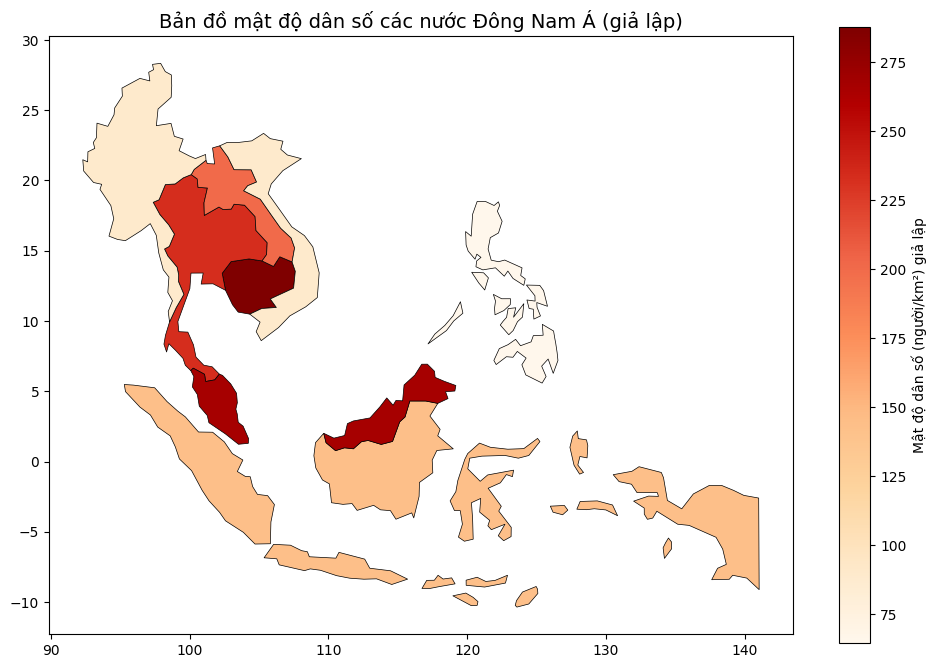

Nhận xét quản trị: Vùng có mật độ cao (màu đỏ) cần ưu tiên đầu tư cơ sở hạ tầng, trung tâm logistics.


In [ ]:
#b4
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Đọc dữ liệu bản đồ thế giới từ NaturalEarth thông qua URL GeoJSON
# This replaces the deprecated gpd.datasets.get_path('naturalearth_lowres')
world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")

# Lọc lấy các nước Đông Nam Á để dễ nhìn
# Sử dụng cột 'REGION_UN' cho châu lục và 'ADMIN' cho tên quốc gia từ GeoJSON
southeast_asia = world[world['REGION_UN'] == 'Asia']
southeast_asia = southeast_asia[southeast_asia['ADMIN'].isin(['Vietnam', 'Laos', 'Cambodia', 'Thailand', 'Myanmar', 'Malaysia', 'Indonesia', 'Philippines'])]

# Tạo cột dân số giả lập (triệu người)
np.random.seed(42)
southeast_asia['pop_density'] = np.random.uniform(50, 300, len(southeast_asia))

# Vẽ bản đồ choropleth
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
southeast_asia.plot(column='pop_density', ax=ax, legend=True,
                    legend_kwds={'label': 'Mật độ dân số (người/km²) giả lập'},
                    cmap='OrRd', edgecolor='black', linewidth=0.5)
ax.set_title("Bản đồ mật độ dân số các nước Đông Nam Á (giả lập)", fontsize=14)
plt.show()

print('Nhận xét quản trị: Vùng có mật độ cao (màu đỏ) cần ưu tiên đầu tư cơ sở hạ tầng, trung tâm logistics.')

In [70]:
#b5
import folium
from geopy.distance import geodesic
center = [10.7629, 106.6825]
m = folium.Map(location=center, zoom_start=12)
folium.Circle(radius=3000, location=center, color='blue', fill=False).add_to(m)  # 3km
folium.Circle(radius=5000, location=center, color='green', fill=False).add_to(m)  # 5km
# Giả lập 5 khách hàng
khach = [[10.7700, 106.6900], [10.7550, 106.6750], [10.7800, 106.7100], [10.7650, 106.6850], [10.7720, 106.6800]]
for k in khach:
    folium.Marker(k, icon=folium.Icon(color='red')).add_to(m)
    # Kiểm tra trong bán kính 5km
    if geodesic(center, k).km <= 5:
        print("Khách", k, "trong vùng 5km")
m
print("Đánh giá: Vòng 3km phục vụ khách hàng trung tâm (giao hàng nhanh), 5km mở rộng, 10km bao phủ toàn bộ quận nội thành. Nên chọn bán kính 5km để cân bằng chi phí và thời gian.")
m

Khách [10.77, 106.69] trong vùng 5km
Khách [10.755, 106.675] trong vùng 5km
Khách [10.78, 106.71] trong vùng 5km
Khách [10.765, 106.685] trong vùng 5km
Khách [10.772, 106.68] trong vùng 5km
Đánh giá: Vòng 3km phục vụ khách hàng trung tâm (giao hàng nhanh), 5km mở rộng, 10km bao phủ toàn bộ quận nội thành. Nên chọn bán kính 5km để cân bằng chi phí và thời gian.


In [72]:
#b6
import osmnx as ox
import matplotlib.pyplot as plt

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(10, 8))

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
total_length = sum(data['length'] for u, v, data in G.edges(data=True))
avg_edge_length = total_length / n_edges
print(f"Số nút giao thông: {n_nodes}")
print(f"Số đoạn đường (cạnh): {n_edges}")
print(f"Tổng chiều dài mạng lưới: {total_length/1000:.2f} km")
print(f"Chiều dài trung bình mỗi cạnh: {avg_edge_length:.2f} m")
print("Vai trò: Dữ liệu mạng giao thông giúp AI đô thị thông minh dự báo tắc nghẽn, tìm đường tối ưu, quản lý đèn giao thông.")

<IPython.core.display.Javascript object>

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [84]:
#b7
import osmnx as ox
import networkx as nx
import random

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

nodes = list(G.nodes())
start_node = random.choice(nodes)
end_node = random.choice(nodes)

path_dijkstra = nx.shortest_path(G, start_node, end_node, weight='length')
path_astar = nx.astar_path(G, start_node, end_node, weight='length')

print(f"Đường đi Dijkstra: {path_dijkstra}")
print(f"Đường đi A*: {path_astar}")

fig, ax = ox.plot_graph_routes(
    G,
    routes=[path_dijkstra, path_astar],
    route_colors=['red', 'blue'],
    route_linewidths=[6, 2],
    node_size=0
)

print(f"Độ dài Dijkstra: {nx.path_weight(G, path_dijkstra, weight='length'):.2f} mét")
print(f"Độ dài A*: {nx.path_weight(G, path_astar, weight='length'):.2f} mét")
print("\nPhân tích:")
print("- Dijkstra: Đảm bảo tìm đường ngắn nhất tuyệt đối bằng cách duyệt rộng.")
print("- A*: Tìm nhanh hơn nhờ sử dụng hàm heuristic để định hướng tìm kiếm.")

Đường đi Dijkstra: [1769173835, 411918792, 411918789, 9622589906, 9582474882, 13521117630, 13521117633, 6639705121, 6639705119, 9646671008, 2036082874, 8141066129, 11510232020, 2036082840, 6858588499, 10991234693, 2974077439, 13514030147, 1769692389, 2403047190, 4099242263, 411926704, 411919278, 411926705, 11364187677, 6637183621, 6637183630, 411925996, 411926524, 6637081017, 6637081019, 366440881, 11064388833, 11064388835, 7940916996, 7940916999, 7940917001, 411921460, 13271508799, 411921451, 411921464, 2332680419]
Đường đi A*: [1769173835, 411918792, 411918789, 9622589906, 9582474882, 13521117630, 13521117633, 6639705121, 6639705119, 9646671008, 2036082874, 8141066129, 11510232020, 2036082840, 6858588499, 10991234693, 2974077439, 13514030147, 1769692389, 2403047190, 4099242263, 411926704, 411919278, 411926705, 11364187677, 6637183621, 6637183630, 411925996, 411926524, 6637081017, 6637081019, 366440881, 11064388833, 11064388835, 7940916996, 7940916999, 7940917001, 411921460, 132715087

<IPython.core.display.Javascript object>

Độ dài Dijkstra: 3542.63 mét
Độ dài A*: 3542.63 mét

Phân tích:
- Dijkstra: Đảm bảo tìm đường ngắn nhất tuyệt đối bằng cách duyệt rộng.
- A*: Tìm nhanh hơn nhờ sử dụng hàm heuristic để định hướng tìm kiếm.


In [77]:
#b8
import folium
import numpy as np

# Giả lập vị trí 5 khách hàng và 3 xe
np.random.seed(42)
customers = {f"KH{i}": (10.76 + np.random.uniform(-0.02,0.02), 106.68 + np.random.uniform(-0.02,0.02)) for i in range(5)}
cars = {f"Xe{i}": (10.77 + np.random.uniform(-0.02,0.02), 106.69 + np.random.uniform(-0.02,0.02)) for i in range(3)}

# Hàm khoảng cách Euclidean (đơn giản hóa)
def distance(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

# Gán mỗi khách hàng cho xe gần nhất
assignments = {}
for cid, cpos in customers.items():
    best_car = min(cars.keys(), key=lambda x: distance(cars[x], cpos))
    assignments[cid] = best_car

# Vẽ bản đồ
m = folium.Map(location=[10.765, 106.685], zoom_start=14)
for cid, pos in customers.items():
    folium.Marker(pos, popup=f"{cid}", icon=folium.Icon(color='blue')).add_to(m)
for car, pos in cars.items():
    folium.Marker(pos, popup=f"{car}", icon=folium.Icon(color='green')).add_to(m)
for cid, car in assignments.items():
    folium.PolyLine([customers[cid], cars[car]], color='red', weight=2, opacity=0.6).add_to(m)

print("Heuristic: gán xe dựa trên khoảng cách Euclidean (có thể thay bằng thời gian di chuyển thực tế từ OSMnx).")

Heuristic: gán xe dựa trên khoảng cách Euclidean (có thể thay bằng thời gian di chuyển thực tế từ OSMnx).


In [81]:
#b9
import numpy as np
import folium
from sklearn.cluster import KMeans

# Tạo dữ liệu 200 khách hàng
np.random.seed(0)
coords = np.random.uniform(low=[10.75, 106.67], high=[10.78, 106.70], size=(200,2))

# Phân cụm thành 4 cụm (số lượng trạm dự kiến)
kmeans = KMeans(n_clusters=4, random_state=0).fit(coords)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Vẽ bản đồ
m = folium.Map(location=[10.765, 106.685], zoom_start=14)
colors = ['red', 'blue', 'green', 'purple']
for i, (lat, lon) in enumerate(coords):
    folium.CircleMarker([lat, lon], radius=3, color=colors[labels[i]], fill=True, fill_opacity=0.6).add_to(m)
for i, (lat, lon) in enumerate(centers):
    folium.Marker([lat, lon], popup=f"Đề xuất trạm {i+1}", icon=folium.Icon(color='darkred')).add_to(m)


print("Logic quản trị: Đặt kho hàng/trạm xe tại tâm mỗi cụm để giảm khoảng cách trung bình đến khách hàng, tối ưu chi phí vận hành.")
m

Tâm cụm: [[ 10.78       106.70166667]
 [ 10.76212857 106.68178571]]
Nhãn: [1 1 1 0 1 1 1 0 1 0]


In [83]:
#b10
import folium
import numpy as np

# Giả lập các tuyến đường với mức độ tắc nghẽn (0-1)
roads = [
    {"name": "Đường Nguyễn Huệ", "coords": [[10.7769,106.7009], [10.7700,106.6950]], "risk": 0.8},
    {"name": "Đường Lê Lợi", "coords": [[10.7769,106.7009], [10.7800,106.6900]], "risk": 0.3},
    {"name": "Đường Cách Mạng Tháng 8", "coords": [[10.7629,106.6825], [10.7700,106.6950]], "risk": 0.9},
    {"name": "Đường Võ Văn Kiệt", "coords": [[10.7629,106.6825], [10.7550,106.6800]], "risk": 0.2}
]

m = folium.Map(location=[10.765, 106.685], zoom_start=14)
for road in roads:
    # Phân loại màu dựa trên nguy cơ
    if road["risk"] > 0.7:
        color = "red"
    elif road["risk"] > 0.4:
        color = "orange"
    else:
        color = "green"
    folium.PolyLine(road["coords"], color=color, weight=5, popup=f"{road['name']} - Nguy cơ: {road['risk']}").add_to(m)

# Đề xuất tuyến thay thế: đường có risk thấp
print("Đề xuất: Sử dụng các tuyến màu xanh hoặc cam thay vì tuyến đỏ để giảm thời gian di chuyển.")
m

Đề xuất: Sử dụng các tuyến màu xanh hoặc cam thay vì tuyến đỏ để giảm thời gian di chuyển.


In [85]:
#b11
khu_vuc = {"Trung tâm": (10.7769,106.7009, 100), "Ngoại ô": (10.7500,106.6700, 30), "Ven": (10.7700,106.6900, 60)}
for kv, (lat, lon, nhu_cau) in khu_vuc.items():
    print(kv, "- nhu cầu:", nhu_cau)

Trung tâm - nhu cầu: 100
Ngoại ô - nhu cầu: 30
Ven - nhu cầu: 60


In [96]:
#b12
import folium
import itertools
from geopy.distance import geodesic

kho = (10.7769, 106.7009)
khach = {
    "A": (10.7629, 106.6825),
    "B": (10.7700, 106.6900),
    "C": (10.7800, 106.7100)
}

# Tính tổng km cho một thứ tự
def tong(route_names):
    points = [kho] + [khach[n] for n in route_names] + [kho]
    return sum(geodesic(points[i], points[i+1]).km for i in range(len(points)-1))

# Tìm thứ tự tối ưu (chỉ 6 hoán vị)
best = min(itertools.permutations(khach.keys()), key=tong)
best_dist = tong(best)
# Lấy một thứ tự bất kỳ để so sánh (ví dụ A->B->C)
other = ("A", "B", "C")
other_dist = tong(other)

print(f"Tối ưu: {' → '.join(best)} = {best_dist:.2f} km")
print(f"Thứ tự khác: {' → '.join(other)} = {other_dist:.2f} km")
print(f"Chênh lệch: {other_dist - best_dist:.2f} km")

# Vẽ bản đồ
m = folium.Map(location=kho, zoom_start=13)
folium.Marker(kho, popup="Kho", icon=folium.Icon(color='red')).add_to(m)
for name, coord in khach.items():
    folium.Marker(coord, popup=name).add_to(m)

# Vẽ tuyến tối ưu (xanh)
route_best = [kho] + [khach[n] for n in best] + [kho]
folium.PolyLine(route_best, color='green', weight=5, popup=f"Tối ưu {best_dist} km").add_to(m)

# Vẽ tuyến khác (xám đứt)
route_other = [kho] + [khach[n] for n in other] + [kho]
folium.PolyLine(route_other, color='gray', weight=3, dash_array='5', popup=f"{other_dist} km").add_to(m)

m

Tối ưu: B → A → C = 7.16 km
Thứ tự khác: A → B → C = 7.18 km
Chênh lệch: 0.02 km


In [87]:
#b13
import folium
m = folium.Map(location=[10.7629,106.6825], zoom_start=13)
# Lớp điểm
fg_point = folium.FeatureGroup(name="Điểm")
folium.Marker([10.7629,106.6825], popup="UEH").add_to(fg_point)
# Lớp vùng
fg_area = folium.FeatureGroup(name="Vùng")
folium.Circle(radius=1000, location=[10.7629,106.6825], color='blue', fill=True).add_to(fg_area)
fg_point.add_to(m)
fg_area.add_to(m)
folium.LayerControl().add_to(m)
m

In [94]:
#b14
import folium
import time
from IPython.display import display, clear_output

# Xe bắt đầu từ A, đến B
A = (10.7629, 106.6825)   # UEH
B = (10.7769, 106.7009)   # Nhà hát TP.HCM

# Tạo bản đồ nền
m_goc = folium.Map(location=A, zoom_start=14)
folium.Marker(A, popup="Điểm xuất phát", icon=folium.Icon(color='green')).add_to(m_goc)
folium.Marker(B, popup="Điểm đến", icon=folium.Icon(color='red')).add_to(m_goc)

# Mô phỏng 5 bước di chuyển
for step in range(6):
    # Vị trí hiện tại (nội suy tuyến tính)
    lat = A[0] + (step/5) * (B[0] - A[0])
    lon = A[1] + (step/5) * (B[1] - A[1])

    # Tạo bản đồ mới cho mỗi bước (hoặc copy)
    m = folium.Map(location=[(A[0]+B[0])/2, (A[1]+B[1])/2], zoom_start=14)
    folium.Marker(A, popup="Xuất phát", icon=folium.Icon(color='green')).add_to(m)
    folium.Marker(B, popup="Đích", icon=folium.Icon(color='red')).add_to(m)
    folium.Marker((lat, lon), popup=f"Xe - bước {step}", icon=folium.Icon(color='blue')).add_to(m)
    # Vẽ đường đã đi từ A đến vị trí hiện tại
    folium.PolyLine([A, (lat, lon)], color='orange', weight=3).add_to(m)

    clear_output(wait=True)
    display(m)
    time.sleep(1)

In [90]:
#b15
import folium
# Giả sử có 3 trường học
truong = [[10.7629,106.6825], [10.7700,106.6900], [10.7550,106.6750]]
# Tính tâm trung bình làm trạm đề xuất
lat_tb = sum(p[0] for p in truong)/3
lon_tb = sum(p[1] for p in truong)/3
m = folium.Map(location=[lat_tb, lon_tb], zoom_start=13)
for t in truong:
    folium.Marker(t, popup="Trường học").add_to(m)
folium.Marker([lat_tb, lon_tb], popup="Trạm đề xuất", icon=folium.Icon(color='red')).add_to(m)
m